# PyG GCN/GAT on your RAW Reactome DAG (sanity + imbalance fixes incl. focal loss)

This notebook is a focused check that **vanilla PyTorch Geometric** models train on **your** generated raw DAG (`outputs/graph/`) and TCGA matrix.

It includes:
- Graph diagnostics + a small connectivity visualization
- A clean patient-graph dataset (same topology per patient)
- Readout ablations (pool genes vs roots vs all nodes)
- Imbalance handling options: weighted BCE, **focal loss**, and optional balanced sampling

Goal: get GCN/GAT away from chance and into a stable regime before any larger BINN vs GNN comparison.


In [4]:
import sys
from pathlib import Path
import os

PROJECT_ROOT = Path("/home/maani/niloo/binn_gnn_repo_ready/binn_gnn_repo_ready")

sys.path.append(str(PROJECT_ROOT / "src"))
os.environ["BINN_GNN_BASE"] = str(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
BASE_DIR = Path(os.environ.get("BINN_GNN_BASE", ".")).resolve()

Project root: /home/maani/niloo/binn_gnn_repo_ready/binn_gnn_repo_ready


In [5]:

# Ensure imports work if you have a src/ layout
if (PROJECT_ROOT / "src").exists():
    sys.path.append(str(PROJECT_ROOT / "src"))

print("PROJECT_ROOT:", PROJECT_ROOT)

OUT_DIR = PROJECT_ROOT / "outputs"
RAW_GRAPH_DIR = OUT_DIR / "graph"
EXPR_PARQUET = OUT_DIR / "expr_reactome_tcga_tumor_normal.parquet"
Y_CSV = OUT_DIR / "y_tcga_tumor_normal.csv"


PROJECT_ROOT: /home/maani/niloo/binn_gnn_repo_ready/binn_gnn_repo_ready


In [6]:
# === 1) Install / import dependencies ===
# (Safe to rerun in Colab)
!pip -q install torch-geometric networkx scikit-learn matplotlib tqdm

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

import networkx as nx
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [7]:
# === 2) Load expression + labels ===
expr = pd.read_parquet(EXPR_PARQUET)  # genes x samples
y_df = pd.read_csv(Y_CSV, index_col=0)

samples = y_df.index.astype(str).tolist()
y = y_df.iloc[:, 0].to_numpy(dtype=np.int64)

expr = expr.loc[:, samples]  # align

print("expr:", expr.shape, "(genes x samples)")
print("y:", y.shape, "pos rate:", float(y.mean()))


expr: (11403, 9912) (genes x samples)
y: (9912,) pos rate: 0.9266545601291364


In [8]:
# === 3) Load raw graph + diagnostics ===
node_table = pd.read_csv(RAW_GRAPH_DIR / "node_table.csv")
edge_index = torch.load(RAW_GRAPH_DIR / "edge_index.pt").long()

num_nodes = node_table.shape[0]
num_edges = edge_index.shape[1]
print("num_nodes:", num_nodes, "| num_edges:", num_edges)

# Directed graph diagnostics
G_dir = nx.DiGraph()
G_dir.add_nodes_from(range(num_nodes))
G_dir.add_edges_from(edge_index.t().tolist())

print("Is DAG?", nx.is_directed_acyclic_graph(G_dir))

type_counts = node_table["node_type"].value_counts()
print("node types:\n", type_counts)

# Roots in this orientation = out_degree==0
out_deg = dict(G_dir.out_degree())
root_nodes = [n for n, d in out_deg.items() if d == 0]
print("root_nodes:", len(root_nodes))

# Undirected connectivity
G_und = G_dir.to_undirected()
comps = list(nx.connected_components(G_und))
sizes = sorted([len(c) for c in comps], reverse=True)
print("Connected components (undirected):", len(comps))
print("Largest component size:", sizes[0], f"({sizes[0]/num_nodes*100:.1f}%)")
print("Isolated nodes:", sum(1 for n in G_und.nodes() if G_und.degree(n)==0))

# Reachability: fraction that can reach ANY root (in directed sense)
# (Compute by reversing edges and doing multi-source BFS from roots)
G_rev = G_dir.reverse(copy=False)
reachable = set()
for r in root_nodes:
    reachable |= nx.descendants(G_rev, r) | {r}
print("Nodes that can reach some root:", len(reachable), f"({len(reachable)/num_nodes*100:.1f}%)")


num_nodes: 14201 | num_edges: 140581


/tmp/ipykernel_1335552/3829275902.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(RAW_GRAPH_DIR / "edge_index.pt").long()


Is DAG? True
node types:
 node_type
gene       11403
pathway     2798
Name: count, dtype: int64
root_nodes: 29
Connected components (undirected): 1
Largest component size: 14201 (100.0%)
Isolated nodes: 0
Nodes that can reach some root: 14201 (100.0%)


Subgraph nodes: 200 edges: 199


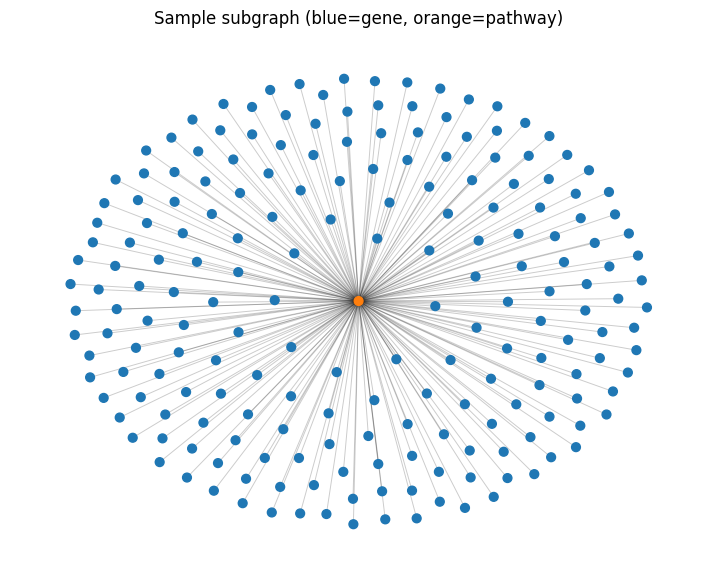

In [9]:
# === 4) Visualize a small subgraph for connectivity sanity ===
import random
random.seed(0)

start = root_nodes[0] if len(root_nodes)>0 else random.randrange(num_nodes)

N_VIS = 200
visited = {start}
queue = [start]
while queue and len(visited) < N_VIS:
    v = queue.pop(0)
    for u in G_und.neighbors(v):
        if u not in visited:
            visited.add(u)
            queue.append(u)
        if len(visited) >= N_VIS:
            break

sub_nodes = sorted(list(visited))
H = G_und.subgraph(sub_nodes).copy()
print("Subgraph nodes:", H.number_of_nodes(), "edges:", H.number_of_edges())

pos = nx.spring_layout(H, seed=0, k=0.5)
node_types = node_table.set_index("node_id")["node_type"].to_dict()
colors = ["tab:blue" if node_types[n]=="gene" else "tab:orange" for n in H.nodes()]

plt.figure(figsize=(9,7))
nx.draw_networkx_edges(H, pos, alpha=0.2, width=0.7)
nx.draw_networkx_nodes(H, pos, node_size=40, node_color=colors)
plt.title("Sample subgraph (blue=gene, orange=pathway)")
plt.axis("off")
plt.show()


In [10]:
# === 5) Build a PyG dataset (patients share topology) ===

from torch.utils.data import WeightedRandomSampler

# Map expr genes -> node ids
gene_rows = node_table.query("node_type=='gene'")[["node_name","node_id"]].copy()
gene_to_id = dict(zip(gene_rows["node_name"].astype(str), gene_rows["node_id"].astype(int)))

expr_genes = expr.index.astype(str).tolist()
genes_in_graph = [g for g in expr_genes if g in gene_to_id]
expr_f = expr.loc[genes_in_graph].copy()

gene_node_ids = torch.tensor([gene_to_id[g] for g in expr_f.index.astype(str)], dtype=torch.long)

print("Genes:", len(expr_genes), "| in graph:", len(genes_in_graph))

# Train/val split ONCE (keep this fixed for fair comparisons)
idx = np.arange(expr_f.shape[1])
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)

# Standardize genes using train split only
X_all = expr_f.T.to_numpy(dtype=np.float32)   # samples x genes
scaler = StandardScaler()
X_all[train_idx] = scaler.fit_transform(X_all[train_idx])
X_all[val_idx]   = scaler.transform(X_all[val_idx])

print("pos rate (full):", float(y.mean()))

# Optional: balanced subset for stability (recommended for debugging AUC)
BALANCE = True
MAX_PER_CLASS = 400  # increase once it works

rng = np.random.default_rng(0)

if BALANCE:
    y_train = y[train_idx]
    pos = train_idx[y_train==1]
    neg = train_idx[y_train==0]
    n = min(len(pos), len(neg), MAX_PER_CLASS)
    train_idx = np.concatenate([rng.choice(pos, n, replace=False), rng.choice(neg, n, replace=False)])

    y_val = y[val_idx]
    pos = val_idx[y_val==1]
    neg = val_idx[y_val==0]
    n = min(len(pos), len(neg), MAX_PER_CLASS)
    val_idx = np.concatenate([rng.choice(pos, n, replace=False), rng.choice(neg, n, replace=False)])

print("train:", len(train_idx), "val:", len(val_idx), "pos rate train:", float(y[train_idx].mean()))

# Edge handling toggles
# For hierarchical DAGs, start with directed edges. If training is unstable, try undirected.
MAKE_UNDIRECTED = False

edge_index_use = edge_index
if MAKE_UNDIRECTED:
    edge_rev = edge_index.flip(0)
    edge_index_use = torch.cat([edge_index, edge_rev], dim=1)
    edge_index_use = torch.unique(edge_index_use, dim=1)

print("edge_index_use:", tuple(edge_index_use.shape), "undirected:", MAKE_UNDIRECTED)

# Masks for pooling
gene_mask_single = torch.zeros(num_nodes, dtype=torch.bool)
gene_mask_single[gene_node_ids] = True

root_mask_single = torch.zeros(num_nodes, dtype=torch.bool)
root_mask_single[torch.tensor(root_nodes, dtype=torch.long)] = True

# Add a 2nd feature: node type indicator (gene=0, pathway=1)
node_is_pathway = (node_table["node_type"].values == "pathway").astype(np.float32)
node_type_feat = torch.from_numpy(node_is_pathway).view(-1,1)  # [num_nodes,1]

class PatientGraphDataset(torch.utils.data.Dataset):
    def __init__(self, indices):
        self.indices = np.array(indices, dtype=int)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, k):
        i = int(self.indices[k])

        # x has 2 dims: [expression, node_type]
        x = torch.zeros((num_nodes, 2), dtype=torch.float32)
        x[gene_node_ids, 0] = torch.from_numpy(X_all[i])  # expression
        x[:, 1:2] = node_type_feat                         # type indicator

        data = Data(
            x=x,
            edge_index=edge_index_use,
            y=torch.tensor([y[i]], dtype=torch.float32),
            gene_mask=gene_mask_single,
            root_mask=root_mask_single
        )
        return data

train_ds = PatientGraphDataset(train_idx)
val_ds   = PatientGraphDataset(val_idx)

BATCH_SIZE = 16

# Option: if NOT using balanced subset, you can use a weighted sampler to upsample the minority class.
USE_WEIGHTED_SAMPLER = False  # set True if BALANCE=False and you want upsampling
if USE_WEIGHTED_SAMPLER:
    y_train = y[train_idx]
    # inverse-frequency weights
    w_pos = 1.0 / max((y_train==1).sum(), 1)
    w_neg = 1.0 / max((y_train==0).sum(), 1)
    sample_w = np.where(y_train==1, w_pos, w_neg).astype(np.float32)
    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

print("Dataset ready.")


Genes: 11403 | in graph: 11403
pos rate (full): 0.9266545601291364
train: 800 val: 290 pos rate train: 0.5
edge_index_use: (2, 140581) undirected: False
Dataset ready.


In [11]:
# === 6) Vanilla GCN/GAT with configurable readout + focal loss ===
from torch_geometric.nn import global_add_pool

def pooled_readout(x, batch, mask, mode="mean"):
    # mask is boolean over nodes in the *batched* tensor
    x_m = x[mask]
    b_m = batch[mask]
    if mode == "mean":
        return global_mean_pool(x_m, b_m)
    elif mode == "sum":
        return global_add_pool(x_m, b_m)
    else:
        raise ValueError(mode)

class BinaryFocalLossWithLogits(nn.Module):
    '''
    Binary focal loss on logits.

    alpha_pos weights y=1, alpha_neg weights y=0.
    gamma controls focusing on hard examples.
    '''
    def __init__(self, alpha_pos=0.5, alpha_neg=0.5, gamma=2.0, reduction="mean"):
        super().__init__()
        assert reduction in ("none", "mean", "sum")
        self.alpha_pos = float(alpha_pos)
        self.alpha_neg = float(alpha_neg)
        self.gamma = float(gamma)
        self.reduction = reduction

    def forward(self, logits, targets):
        targets = targets.float()
        logits = logits.view_as(targets)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        pt = p * targets + (1 - p) * (1 - targets)
        alpha_t = self.alpha_pos * targets + self.alpha_neg * (1 - targets)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

class VanillaGCN(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=64, num_layers=2, dropout=0.1, pool="gene"):
        super().__init__()
        self.pool = pool  # "gene" | "root" | "all"
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim))
        for _ in range(num_layers-1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.lin = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        if self.pool == "all":
            g = global_mean_pool(x, batch)
        elif self.pool == "gene":
            g = pooled_readout(x, batch, data.gene_mask, mode="mean")
        elif self.pool == "root":
            g = pooled_readout(x, batch, data.root_mask, mode="mean")
        else:
            raise ValueError(self.pool)

        return self.lin(g).view(-1)

class VanillaGAT(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=32, heads=4, num_layers=2, dropout=0.1, pool="gene"):
        super().__init__()
        self.pool = pool
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout))
        in_h = hidden_dim * heads
        for _ in range(num_layers-2):
            self.convs.append(GATConv(in_h, hidden_dim, heads=heads, dropout=dropout))
            in_h = hidden_dim * heads
        # last layer reduces to hidden_dim
        if num_layers > 1:
            self.convs.append(GATConv(in_h, hidden_dim, heads=1, concat=True, dropout=dropout))

        self.lin = nn.Linear(hidden_dim if num_layers>1 else in_h, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        if self.pool == "all":
            g = global_mean_pool(x, batch)
        elif self.pool == "gene":
            g = pooled_readout(x, batch, data.gene_mask, mode="mean")
        elif self.pool == "root":
            g = pooled_readout(x, batch, data.root_mask, mode="mean")
        else:
            raise ValueError(self.pool)

        return self.lin(g).view(-1)

def eval_auc(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch)
            prob = torch.sigmoid(logits).cpu().numpy()
            ys.append(batch.y.view(-1).cpu().numpy())
            ps.append(prob)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    return float(roc_auc_score(y_true, y_pred))

def train_model(model, epochs=30, lr=3e-3, weight_decay=1e-5, loss_mode="weighted_bce", focal_gamma=2.0):
    '''
    loss_mode:
      - "bce": plain BCEWithLogits
      - "weighted_bce": per-sample reweighting by inverse class frequency
      - "focal": focal loss with alpha derived from class frequencies (gamma=focal_gamma)
    '''
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Class counts from THIS train split
    y_train = y[train_idx]
    n_pos = int((y_train==1).sum())
    n_neg = int((y_train==0).sum())
    print(f"train class counts: n_pos={n_pos} n_neg={n_neg}  (pos rate {float(y_train.mean()):.3f})")

    # Loss setup
    if loss_mode == "bce":
        loss_fn = nn.BCEWithLogitsLoss()

    elif loss_mode == "weighted_bce":
        # weights sum to ~1 across classes
        w_pos = 0.5 / max(n_pos, 1)
        w_neg = 0.5 / max(n_neg, 1)

    elif loss_mode == "focal":
        # alpha weights inverse to frequency
        alpha_pos = n_neg / max(n_pos + n_neg, 1)
        alpha_neg = n_pos / max(n_pos + n_neg, 1)
        loss_fn = BinaryFocalLossWithLogits(alpha_pos=alpha_pos, alpha_neg=alpha_neg, gamma=focal_gamma)
        print(f"focal alpha_pos={alpha_pos:.3f} alpha_neg={alpha_neg:.3f} gamma={float(focal_gamma):.2f}")

    else:
        raise ValueError(loss_mode)

    hist = {"train_loss": [], "val_auc": []}
    for ep in range(1, epochs+1):
        model.train()
        losses = []
        for batch in train_loader:
            batch = batch.to(device)
            opt.zero_grad()
            logits = model(batch)
            target = batch.y.view(-1)

            if loss_mode == "weighted_bce":
                per = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
                w = torch.where(
                    target > 0.5,
                    torch.tensor(w_pos, device=per.device),
                    torch.tensor(w_neg, device=per.device),
                )
                loss = (per * w).mean()
            else:
                loss = loss_fn(logits, target)

            loss.backward()
            opt.step()
            losses.append(loss.item())

        val_auc = eval_auc(model, val_loader)
        hist["train_loss"].append(float(np.mean(losses)))
        hist["val_auc"].append(val_auc)
        print(f"epoch {ep:03d} | loss {hist['train_loss'][-1]:.4f} | val_auc {val_auc:.4f}")

    return model, hist



==== GCN_gene_weightedBCE ====
train class counts: n_pos=400 n_neg=400  (pos rate 0.500)
epoch 001 | loss 0.0009 | val_auc 0.4701
epoch 002 | loss 0.0009 | val_auc 0.4999
epoch 003 | loss 0.0009 | val_auc 0.5103
epoch 004 | loss 0.0009 | val_auc 0.5115
epoch 005 | loss 0.0009 | val_auc 0.5128
epoch 006 | loss 0.0009 | val_auc 0.5128
epoch 007 | loss 0.0009 | val_auc 0.5133
epoch 008 | loss 0.0009 | val_auc 0.5136
epoch 009 | loss 0.0009 | val_auc 0.5126
epoch 010 | loss 0.0009 | val_auc 0.5141
epoch 011 | loss 0.0009 | val_auc 0.5138
epoch 012 | loss 0.0009 | val_auc 0.5132
epoch 013 | loss 0.0009 | val_auc 0.5138
epoch 014 | loss 0.0009 | val_auc 0.5132
epoch 015 | loss 0.0009 | val_auc 0.5123
epoch 016 | loss 0.0009 | val_auc 0.5141
epoch 017 | loss 0.0009 | val_auc 0.5126
epoch 018 | loss 0.0009 | val_auc 0.5129
epoch 019 | loss 0.0009 | val_auc 0.5139
epoch 020 | loss 0.0009 | val_auc 0.5138
epoch 021 | loss 0.0009 | val_auc 0.5128
epoch 022 | loss 0.0009 | val_auc 0.5124
epoch 02

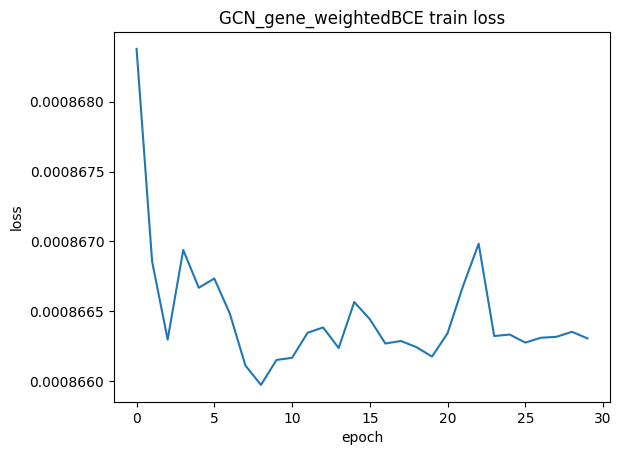

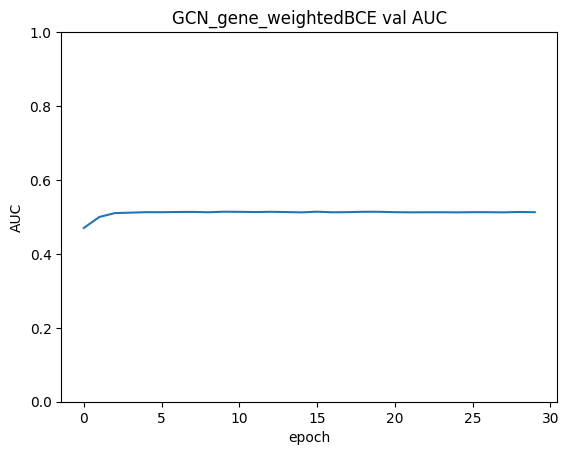


==== GCN_gene_focal_g2 ====
train class counts: n_pos=400 n_neg=400  (pos rate 0.500)
focal alpha_pos=0.500 alpha_neg=0.500 gamma=2.00
epoch 001 | loss 0.0870 | val_auc 0.5149
epoch 002 | loss 0.0868 | val_auc 0.5209
epoch 003 | loss 0.0869 | val_auc 0.5337
epoch 004 | loss 0.0866 | val_auc 0.5314
epoch 005 | loss 0.0863 | val_auc 0.5275
epoch 006 | loss 0.0863 | val_auc 0.5337
epoch 007 | loss 0.0861 | val_auc 0.5310
epoch 008 | loss 0.0862 | val_auc 0.5345
epoch 009 | loss 0.0860 | val_auc 0.5330
epoch 010 | loss 0.0859 | val_auc 0.5327
epoch 011 | loss 0.0862 | val_auc 0.5377
epoch 012 | loss 0.0860 | val_auc 0.5335
epoch 013 | loss 0.0858 | val_auc 0.5334
epoch 014 | loss 0.0859 | val_auc 0.5335
epoch 015 | loss 0.0860 | val_auc 0.5325
epoch 016 | loss 0.0857 | val_auc 0.5332
epoch 017 | loss 0.0856 | val_auc 0.5297
epoch 018 | loss 0.0859 | val_auc 0.5336
epoch 019 | loss 0.0859 | val_auc 0.5320
epoch 020 | loss 0.0858 | val_auc 0.5320
epoch 021 | loss 0.0858 | val_auc 0.5334
epo

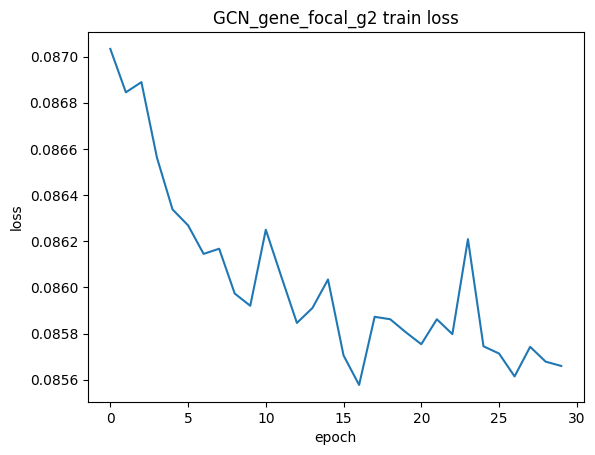

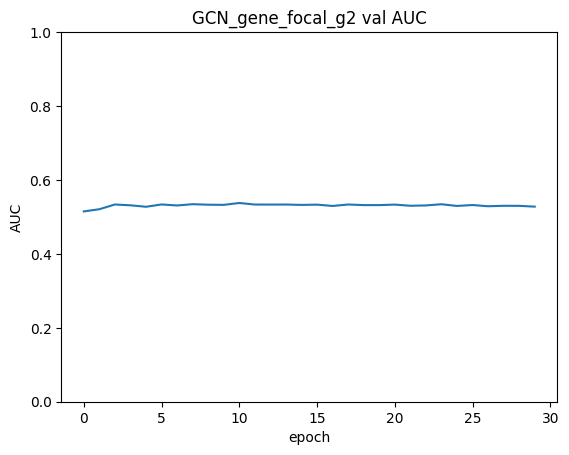


==== GCN_gene_focal_g1 ====
train class counts: n_pos=400 n_neg=400  (pos rate 0.500)
focal alpha_pos=0.500 alpha_neg=0.500 gamma=1.00
epoch 001 | loss 0.1741 | val_auc 0.5225
epoch 002 | loss 0.1730 | val_auc 0.5282
epoch 003 | loss 0.1729 | val_auc 0.5247
epoch 004 | loss 0.1727 | val_auc 0.5319
epoch 005 | loss 0.1725 | val_auc 0.5297
epoch 006 | loss 0.1724 | val_auc 0.5322
epoch 007 | loss 0.1726 | val_auc 0.5308
epoch 008 | loss 0.1721 | val_auc 0.5305
epoch 009 | loss 0.1722 | val_auc 0.5319
epoch 010 | loss 0.1727 | val_auc 0.5292
epoch 011 | loss 0.1720 | val_auc 0.5326
epoch 012 | loss 0.1717 | val_auc 0.5331
epoch 013 | loss 0.1719 | val_auc 0.5317
epoch 014 | loss 0.1721 | val_auc 0.5332
epoch 015 | loss 0.1714 | val_auc 0.5311
epoch 016 | loss 0.1715 | val_auc 0.5323
epoch 017 | loss 0.1716 | val_auc 0.5311
epoch 018 | loss 0.1718 | val_auc 0.5300
epoch 019 | loss 0.1717 | val_auc 0.5323
epoch 020 | loss 0.1714 | val_auc 0.5294
epoch 021 | loss 0.1715 | val_auc 0.5315
epo

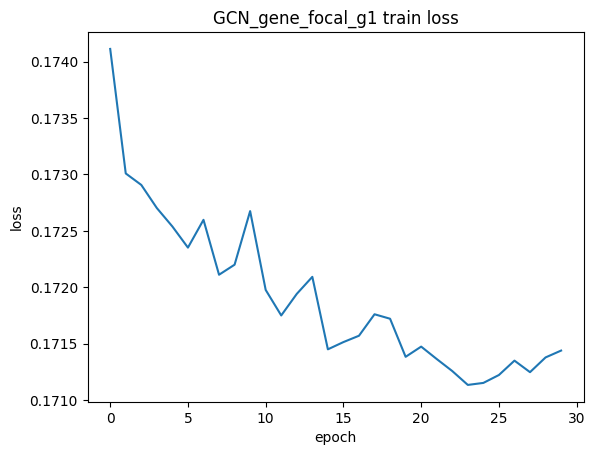

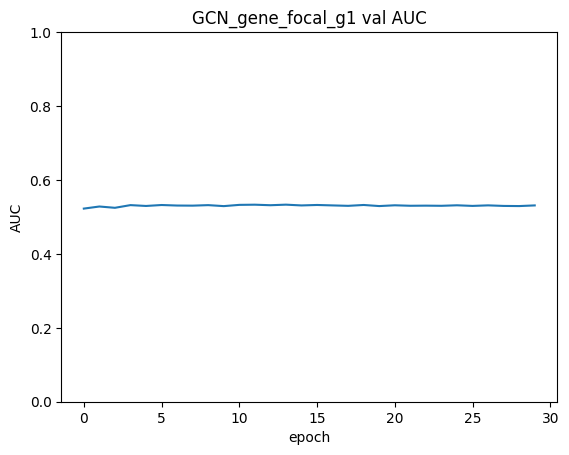


==== GAT_gene_weightedBCE ====
train class counts: n_pos=400 n_neg=400  (pos rate 0.500)
epoch 001 | loss 0.0009 | val_auc 0.5166
epoch 002 | loss 0.0009 | val_auc 0.5163
epoch 003 | loss 0.0009 | val_auc 0.5160
epoch 004 | loss 0.0009 | val_auc 0.5157
epoch 005 | loss 0.0009 | val_auc 0.5155
epoch 006 | loss 0.0009 | val_auc 0.5150
epoch 007 | loss 0.0009 | val_auc 0.5148
epoch 008 | loss 0.0009 | val_auc 0.5151
epoch 009 | loss 0.0009 | val_auc 0.5157
epoch 010 | loss 0.0009 | val_auc 0.5179
epoch 011 | loss 0.0009 | val_auc 0.4758
epoch 012 | loss 0.0009 | val_auc 0.5000
epoch 013 | loss 0.0009 | val_auc 0.5000
epoch 014 | loss 0.0009 | val_auc 0.5000
epoch 015 | loss 0.0009 | val_auc 0.5000
epoch 016 | loss 0.0009 | val_auc 0.5000
epoch 017 | loss 0.0009 | val_auc 0.5000
epoch 018 | loss 0.0009 | val_auc 0.5000
epoch 019 | loss 0.0009 | val_auc 0.5000
epoch 020 | loss 0.0009 | val_auc 0.5000
epoch 021 | loss 0.0009 | val_auc 0.5000
epoch 022 | loss 0.0009 | val_auc 0.5000
epoch 02

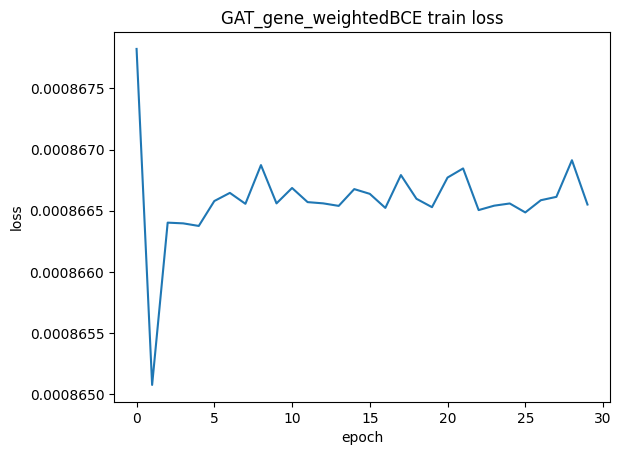

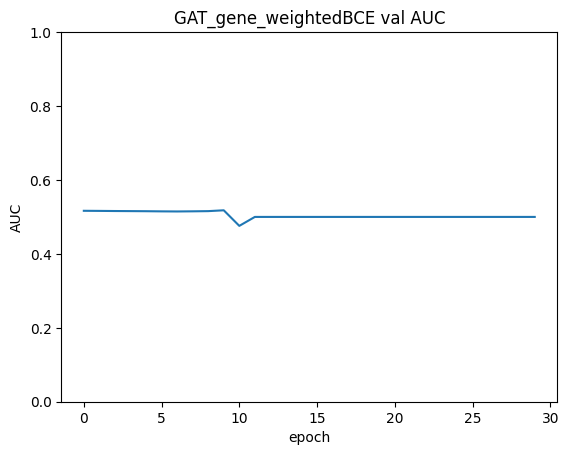


==== GAT_gene_focal_g2 ====
train class counts: n_pos=400 n_neg=400  (pos rate 0.500)
focal alpha_pos=0.500 alpha_neg=0.500 gamma=2.00
epoch 001 | loss 0.0884 | val_auc 0.5200
epoch 002 | loss 0.0864 | val_auc 0.5223
epoch 003 | loss 0.0862 | val_auc 0.5239
epoch 004 | loss 0.0864 | val_auc 0.5295
epoch 005 | loss 0.0863 | val_auc 0.5265
epoch 006 | loss 0.0866 | val_auc 0.5295
epoch 007 | loss 0.0861 | val_auc 0.5286
epoch 008 | loss 0.0860 | val_auc 0.5294
epoch 009 | loss 0.0860 | val_auc 0.5297
epoch 010 | loss 0.0862 | val_auc 0.5290
epoch 011 | loss 0.0859 | val_auc 0.5308
epoch 012 | loss 0.0859 | val_auc 0.5304
epoch 013 | loss 0.0860 | val_auc 0.5298
epoch 014 | loss 0.0859 | val_auc 0.5319
epoch 015 | loss 0.0861 | val_auc 0.5322
epoch 016 | loss 0.0859 | val_auc 0.5302
epoch 017 | loss 0.0860 | val_auc 0.5351
epoch 018 | loss 0.0860 | val_auc 0.5299
epoch 019 | loss 0.0860 | val_auc 0.5314
epoch 020 | loss 0.0860 | val_auc 0.5313
epoch 021 | loss 0.0859 | val_auc 0.5311
epo

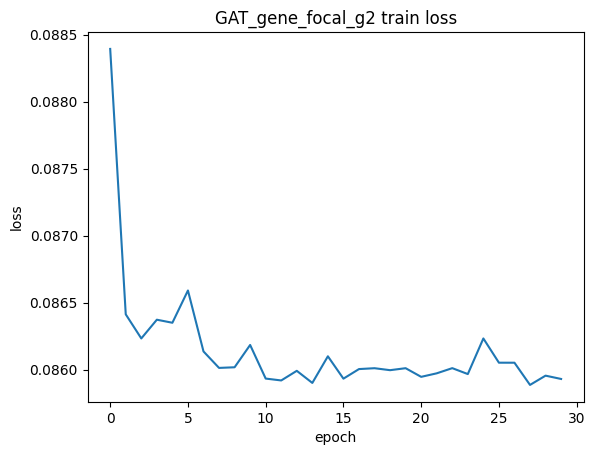

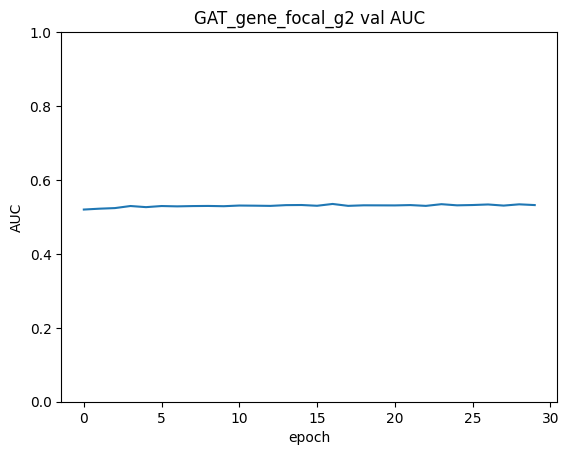


==== GCN_root_weightedBCE ====
train class counts: n_pos=400 n_neg=400  (pos rate 0.500)
epoch 001 | loss 0.0009 | val_auc 0.5794
epoch 002 | loss 0.0009 | val_auc 0.5898
epoch 003 | loss 0.0009 | val_auc 0.5729
epoch 004 | loss 0.0009 | val_auc 0.5916
epoch 005 | loss 0.0009 | val_auc 0.5961
epoch 006 | loss 0.0008 | val_auc 0.5878
epoch 007 | loss 0.0009 | val_auc 0.5978
epoch 008 | loss 0.0008 | val_auc 0.6000
epoch 009 | loss 0.0008 | val_auc 0.5933
epoch 010 | loss 0.0008 | val_auc 0.6153
epoch 011 | loss 0.0008 | val_auc 0.5965
epoch 012 | loss 0.0008 | val_auc 0.6000
epoch 013 | loss 0.0008 | val_auc 0.6092
epoch 014 | loss 0.0008 | val_auc 0.6252
epoch 015 | loss 0.0008 | val_auc 0.6236
epoch 016 | loss 0.0008 | val_auc 0.6149
epoch 017 | loss 0.0008 | val_auc 0.6387
epoch 018 | loss 0.0008 | val_auc 0.6265
epoch 019 | loss 0.0008 | val_auc 0.6107
epoch 020 | loss 0.0008 | val_auc 0.6215
epoch 021 | loss 0.0008 | val_auc 0.6293
epoch 022 | loss 0.0008 | val_auc 0.6300
epoch 02

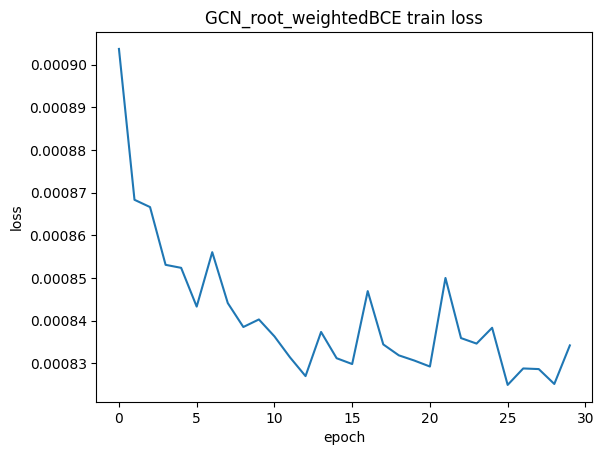

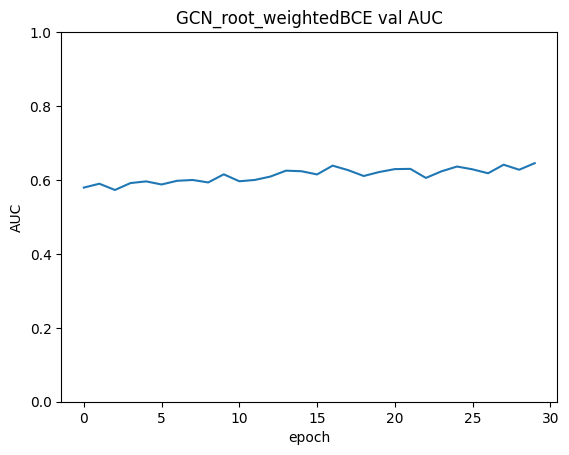


==== GAT_root_weightedBCE ====
train class counts: n_pos=400 n_neg=400  (pos rate 0.500)
epoch 001 | loss 0.0009 | val_auc 0.5772
epoch 002 | loss 0.0009 | val_auc 0.5769
epoch 003 | loss 0.0009 | val_auc 0.5766
epoch 004 | loss 0.0009 | val_auc 0.5449
epoch 005 | loss 0.0009 | val_auc 0.5000
epoch 006 | loss 0.0009 | val_auc 0.5000
epoch 007 | loss 0.0009 | val_auc 0.5000
epoch 008 | loss 0.0009 | val_auc 0.5000
epoch 009 | loss 0.0009 | val_auc 0.5000
epoch 010 | loss 0.0009 | val_auc 0.5000
epoch 011 | loss 0.0009 | val_auc 0.5000
epoch 012 | loss 0.0009 | val_auc 0.5000
epoch 013 | loss 0.0009 | val_auc 0.5000
epoch 014 | loss 0.0009 | val_auc 0.5000
epoch 015 | loss 0.0009 | val_auc 0.5000
epoch 016 | loss 0.0009 | val_auc 0.5000
epoch 017 | loss 0.0009 | val_auc 0.5000
epoch 018 | loss 0.0009 | val_auc 0.5000
epoch 019 | loss 0.0009 | val_auc 0.5000
epoch 020 | loss 0.0009 | val_auc 0.5000
epoch 021 | loss 0.0009 | val_auc 0.5000
epoch 022 | loss 0.0009 | val_auc 0.5000
epoch 02

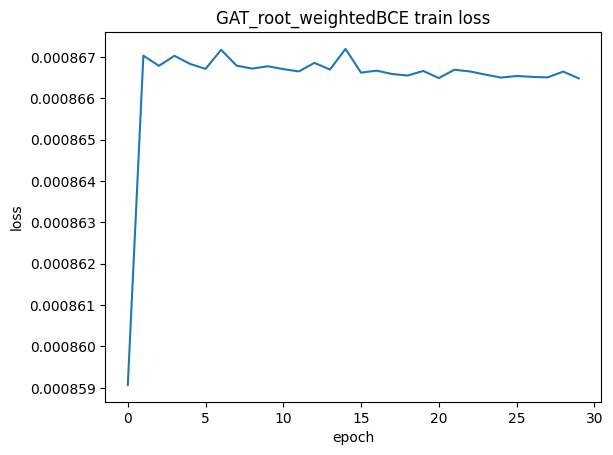

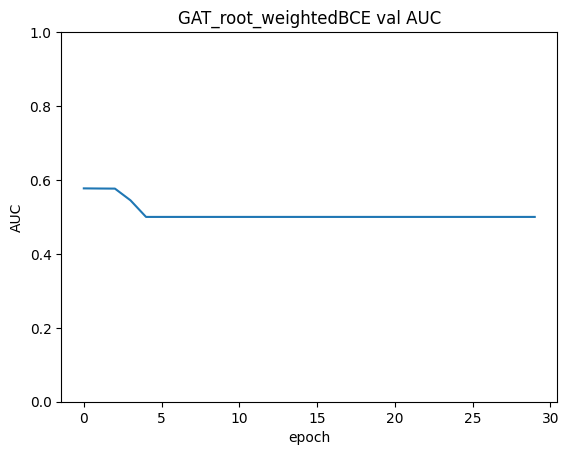


Best val AUC per config:


,config,best_val_auc,best_epoch
5,GCN_root_weightedBCE,0.645422,30
6,GAT_root_weightedBCE,0.577218,1
1,GCN_gene_focal_g2,0.537693,11
4,GAT_gene_focal_g2,0.535077,17
2,GCN_gene_focal_g1,0.533175,14
3,GAT_gene_weightedBCE,0.517931,10
0,GCN_gene_weightedBCE,0.514102,16


In [12]:
# === 7) Run a few targeted configs (compare weighted BCE vs focal) ===
EPOCHS = 30

configs = [
    # Gene pooling is usually strongest on expression tasks
    ("GCN_gene_weightedBCE", VanillaGCN(hidden_dim=64, num_layers=1, dropout=0.1, pool="gene"),
     dict(lr=3e-3, loss_mode="weighted_bce")),
    ("GCN_gene_focal_g2", VanillaGCN(hidden_dim=64, num_layers=1, dropout=0.1, pool="gene"),
     dict(lr=3e-3, loss_mode="focal", focal_gamma=2.0)),
    ("GCN_gene_focal_g1", VanillaGCN(hidden_dim=64, num_layers=1, dropout=0.1, pool="gene"),
     dict(lr=3e-3, loss_mode="focal", focal_gamma=1.0)),

    ("GAT_gene_weightedBCE", VanillaGAT(hidden_dim=32, heads=4, num_layers=2, dropout=0.1, pool="gene"),
     dict(lr=3e-3, loss_mode="weighted_bce")),
    ("GAT_gene_focal_g2", VanillaGAT(hidden_dim=32, heads=4, num_layers=2, dropout=0.1, pool="gene"),
     dict(lr=3e-3, loss_mode="focal", focal_gamma=2.0)),

    # Root pooling variants (closer to BINN output-at-top intuition)
    ("GCN_root_weightedBCE", VanillaGCN(hidden_dim=64, num_layers=3, dropout=0.1, pool="root"),
     dict(lr=3e-3, loss_mode="weighted_bce")),
    ("GAT_root_weightedBCE", VanillaGAT(hidden_dim=32, heads=4, num_layers=4, dropout=0.1, pool="root"),
     dict(lr=3e-3, loss_mode="weighted_bce")),
]

results = []
for name, model, kw in configs:
    print("\n====", name, "====")
    m, hist = train_model(model, epochs=EPOCHS, weight_decay=1e-5, **kw)
    best_auc = float(np.max(hist["val_auc"]))
    best_ep = int(np.argmax(hist["val_auc"])) + 1
    results.append(dict(config=name, best_val_auc=best_auc, best_epoch=best_ep))

    plt.figure()
    plt.plot(hist["train_loss"])
    plt.title(f"{name} train loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.show()

    plt.figure()
    plt.plot(hist["val_auc"])
    plt.title(f"{name} val AUC")
    plt.xlabel("epoch")
    plt.ylabel("AUC")
    plt.ylim(0,1)
    plt.show()

res_df = pd.DataFrame(results).sort_values("best_val_auc", ascending=False)
print("\nBest val AUC per config:")
display(res_df)


## Interpreting outcomes

If you want AUC to approach ~0.9, do this in order:

1. **Check learnability**: run an MLP on the standardized gene matrix with the same split. If *that* AUC is not near 0.9, the GNN will not magically reach it.
2. **Stabilize the evaluation**: with strong imbalance, use a balanced validation subset (as we do here) or run repeated splits.
3. **Fix pooling**: global mean over all nodes is usually a bad default here. Pool genes or roots.
4. **Handle directionality**: for hierarchical graphs, try directed edges + root pooling; if it fails, try undirected edges.
5. **Then tune hyperparameters**: hidden_dim, layers, dropout, lr.

Once the vanilla models produce reasonable learning curves, you can port the same settings into your main comparison notebook.
